In [ ]:
# CELL 1 — DPT-Hybrid Environment Setup
import os
import sys

print(" Downgrading timm to 0.4.12 for ISL-Org compatibility...")
!pip install -q timm==0.4.12

print(" Cloning official DPT repository...")
if not os.path.exists("/kaggle/working/DPT"):
    !git clone https://github.com/isl-org/DPT.git /kaggle/working/DPT

print(" Downloading DPT-Hybrid ADE20K weights...")
!mkdir -p /kaggle/working/DPT/weights
if not os.path.exists("/kaggle/working/DPT/weights/dpt_hybrid-ade20k-53898607.pt"):
    !wget -q -O /kaggle/working/DPT/weights/dpt_hybrid-ade20k-53898607.pt https://github.com/isl-org/DPT/releases/download/1_0/dpt_hybrid-ade20k-53898607.pt

print(" Setup Complete.")

📦 Downgrading timm to 0.4.12 for ISL-Org compatibility...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 7.8 MB/s eta 0:00:00
🔄 Cloning official DPT repository...
Cloning into '/kaggle/working/DPT'...
remote: Enumerating objects: 782, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 782 (delta 144), reused 113 (delta 113), pack-reused 606 (from 1)
Receiving objects: 100% (782/782), 458.16 KiB | 5.45 MiB/s, done.
Resolving deltas: 100% (371/371), done.
📥 Downloading DPT-Hybrid ADE20K weights...
✅ Setup Complete.


In [ ]:
# CELL 2 — Configuration for DPT-Hybrid
import time
import datetime

CONFIG = {
    "num_classes": 150,
    "image_size": 384,               # Standard for DPT
    "batch_size": 8,                 
    "num_epochs": 10,                 # Set for the 50% data run
    "lr": 2e-5,                      # Recommended lower LR for DPT
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "data_split": 0.1,               # 50% data split
    "val_fraction": 0.1,
    "checkpoint_interval": 1,        
    "max_grad_norm": 1.0,
    "use_amp": True,
    "session_start": time.time(),
    "max_session_hours": 11.5,       
    "precache": False,               
    "num_workers": 4,                # Disk streaming workers
    "persistent_workers": True,      
    "prefetch_factor": 2,            
    "pin_memory": True
}

# ADE20K dataset path
ADE20K_ROOT = "/kaggle/input/datasets/awsaf49/ade20k-dataset/ADEChallengeData2016"

# Unique output directory setup
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
split_tag = f"{int(CONFIG['data_split']*100)}pct"
epoch_tag = f"{CONFIG['num_epochs']}ep"
folder_name = f"dpt_hybrid_ade20k_{split_tag}_{epoch_tag}_{timestamp}"
CONFIG["output_dir"] = f"/kaggle/working/{folder_name}"
os.makedirs(CONFIG["output_dir"], exist_ok=True)

print(f"Outputs will be saved to: {CONFIG['output_dir']}")

💾 Outputs will be saved to: /kaggle/working/dpt_hybrid_ade20k_10pct_10ep_20260412_191626


In [ ]:
# CELL 3 — DPT-Hybrid Dataset Class (Disk-Streaming)
import glob
import torch
import numpy as np
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
from tqdm.notebook import tqdm

class ADE20K_Robust_Dataset(Dataset):
    def __init__(self, split="train", fraction=1.0, image_size=384, local_root=None):
        self.image_size = image_size
        self.local_root = local_root
        self.split = split
        self.fraction = fraction
        
        
        self.image_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
        
        self._load_local_dataset(split, fraction)
            
    def _load_local_dataset(self, split, fraction):
        print(f" Loading local dataset from {self.local_root}...")
        
        if split == "train":
            img_dir = os.path.join(self.local_root, "images", "training")
            ann_dir = os.path.join(self.local_root, "annotations", "training")
        else:
            img_dir = os.path.join(self.local_root, "images", "validation")
            ann_dir = os.path.join(self.local_root, "annotations", "validation")
            
        img_files = glob.glob(os.path.join(img_dir, "*.jpg")) + \
                    glob.glob(os.path.join(img_dir, "*.jpeg")) + \
                    glob.glob(os.path.join(img_dir, "*.png"))
                    
        self.samples = []
        for img_path in img_files:
            base = os.path.splitext(os.path.basename(img_path))[0]
            ann_path = os.path.join(ann_dir, f"{base}.png")
            if os.path.exists(ann_path):
                self.samples.append((img_path, ann_path))
                
        print(f"Loaded {len(self.samples)} image-mask pairs")
        
        if fraction < 1.0:
            n = max(1, int(len(self.samples) * fraction))
            import random
            random.seed(42)
            self.samples = random.sample(self.samples, n)
            print(f"Using {n}/{len(self.samples)} samples ({fraction*100:.0f}%)")
    
    def __len__(self):
        return len(self.samples)
    
    def _process_annotation(self, seg_pil):
        seg_np = np.array(seg_pil, dtype=np.int64)
        if seg_np.ndim == 3 and seg_np.shape[2] == 3:
            seg_np = seg_np[:, :, 0].astype(np.int64)
        
        label = seg_np.copy()
        label[label == 0] = -100                       
        valid_mask = (label >= 1) & (label <= 150)
        label[valid_mask] = label[valid_mask] - 1      
        label[(label < 0) & (label != -100)] = -100
        label[label > 149] = -100
        return label
    
    def __getitem__(self, idx):
        try:
            img_path, ann_path = self.samples[idx]
            image = Image.open(img_path).convert("RGB")
            seg = Image.open(ann_path)
            
            image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
            seg = seg.resize((self.image_size, self.image_size), Image.NEAREST)
            
            pixel_values = self.image_transform(image)
            
            label = self._process_annotation(seg)
            label = torch.from_numpy(label).long()
            
            return {"pixel_values": pixel_values, "labels": label}
            
        except Exception as e:
            print(f"Error loading sample {idx}: {e}")
            return {
                "pixel_values": torch.zeros(3, self.image_size, self.image_size),
                "labels": torch.full((self.image_size, self.image_size), -100, dtype=torch.long)
            }

In [ ]:
# CELL 4 — Initialize Model and Streaming Dataloaders
from torch.utils.data import DataLoader

if '/kaggle/working/DPT' not in sys.path:
    sys.path.append('/kaggle/working/DPT')

from dpt.models import DPTSegmentationModel

print("Building DPT-Hybrid architecture...")
model = DPTSegmentationModel(
    num_classes=150,
    path="/kaggle/working/DPT/weights/dpt_hybrid-ade20k-53898607.pt",
    backbone="vitb_rn50_384"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Model loaded and moved to {device}.")

print("\nCreating streaming datasets...")
train_ds = ADE20K_Robust_Dataset(
    split="train",
    fraction=CONFIG["data_split"],
    image_size=CONFIG["image_size"],
    local_root=ADE20K_ROOT
)

val_ds = ADE20K_Robust_Dataset(
    split="val",
    fraction=CONFIG.get("val_fraction", 1.0),
    image_size=CONFIG["image_size"],
    local_root=ADE20K_ROOT
)

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],          
    pin_memory=CONFIG["pin_memory"],            
    persistent_workers=CONFIG["persistent_workers"], 
    prefetch_factor=CONFIG["prefetch_factor"],  
    drop_last=True                              
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=2,                              
    pin_memory=True,
    persistent_workers=False
)

print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} batches")

🤖 Building DPT-Hybrid architecture...
✅ Model loaded and moved to cuda.

📦 Creating streaming datasets...
📂 Loading local dataset from /kaggle/input/datasets/awsaf49/ade20k-dataset/ADEChallengeData2016...
✅ Loaded 20210 image-mask pairs
📊 Using 2021/2021 samples (10%)
📂 Loading local dataset from /kaggle/input/datasets/awsaf49/ade20k-dataset/ADEChallengeData2016...
✅ Loaded 2000 image-mask pairs
📊 Using 200/200 samples (10%)
✅ Train: 252 batches | Val: 25 batches


In [ ]:
# CELL 5 — DPT-Hybrid Training Loop
import time
import os
import gc
import json
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from torch.cuda.amp import GradScaler, autocast
from tqdm.notebook import tqdm

def compute_miou_batch(preds, labels, num_classes=150, ignore_index=-100):
    preds = preds.flatten()
    labels = labels.flatten()
    valid = labels != ignore_index
    preds, labels = preds[valid], labels[valid]
    if len(labels) == 0: return 0.0, {}
    
    intersection = torch.bincount(num_classes * labels + preds, minlength=num_classes**2).reshape(num_classes, num_classes).diagonal()
    union = torch.bincount(labels, minlength=num_classes) + torch.bincount(preds, minlength=num_classes) - intersection
    ious = intersection.float() / (union.float() + 1e-10)
    
    per_class = {i: ious[i].item() if union[i] > 0 else -1 for i in range(num_classes)}
    valid_ious = ious[union > 0]
    return valid_ious.mean().item() if len(valid_ious) > 0 else 0.0, per_class

# Clean GPU before starting
gc.collect()
torch.cuda.empty_cache()
print(f"GPU Free. Starting VRAM usage: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")

# Optimizer & Scheduler
optimizer = AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
total_steps = len(train_loader) * CONFIG["num_epochs"]
warmup_steps = int(total_steps * CONFIG["warmup_ratio"])
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
scaler = GradScaler(enabled=CONFIG["use_amp"])
torch.backends.cudnn.benchmark = True

checkpoint_path = f"{CONFIG['output_dir']}/dpt_checkpoint.pt"
best_miou = 0.0
history = {"train_loss": [], "val_miou": []}

print(f"\nStarting DPT-Hybrid Training: {CONFIG['num_epochs']} epochs | {int(CONFIG['data_split']*100)}% data")
print("="*60)

for epoch in range(CONFIG["num_epochs"]):
    elapsed_hours = (time.time() - CONFIG["session_start"]) / 3600
    if elapsed_hours > CONFIG["max_session_hours"]:
        print(f"Approaching Kaggle timeout ({elapsed_hours:.1f}h). Saving & exiting gracefully.")
        break

    # --- TRAINING ---
    model.train()
    total_loss, batch_count = 0.0, 0
    progress = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")

    for batch_idx, batch in enumerate(progress):
        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with autocast(enabled=CONFIG["use_amp"]):
            # DPT outputs a raw tensor [B, C, H, W]
            logits = model(pixel_values) 
            logits = F.interpolate(logits, size=labels.shape[-2:], mode='bilinear', align_corners=False)
            loss = F.cross_entropy(logits, labels, ignore_index=-100)

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        batch_count += 1
        progress.set_postfix({"loss": f"{loss.item():.4f}"})
        
        # Periodic VRAM cleanup
        if batch_idx % 50 == 0:
            del logits, loss
            torch.cuda.empty_cache()

    avg_loss = total_loss / batch_count
    history["train_loss"].append(avg_loss)
    print(f"Epoch {epoch+1} Train Loss: {avg_loss:.4f}")

    # --- VALIDATION ---
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad(), tqdm(val_loader, desc="Validating", leave=False) as pbar:
        for batch_idx, batch in enumerate(pbar):
            pixel_values = batch["pixel_values"].to(device, non_blocking=True)
            labels = batch["labels"]
            
            with autocast(enabled=CONFIG["use_amp"]):
                logits = model(pixel_values)
                logits = F.interpolate(logits, size=labels.shape[-2:], mode='bilinear', align_corners=False)
            
            preds = logits.argmax(dim=1).cpu().detach()
            all_preds.append(preds)
            all_labels.append(labels)
            
            if batch_idx % 20 == 0:
                del logits, pixel_values
                torch.cuda.empty_cache()

    if all_preds:
        all_preds_cat = torch.cat(all_preds).cpu()
        all_labels_cat = torch.cat(all_labels).cpu()
        miou, _ = compute_miou_batch(all_preds_cat, all_labels_cat, CONFIG["num_classes"])
    else:
        miou = 0.0
        
    history["val_miou"].append(miou)
    print(f"Epoch {epoch+1} mIoU: {miou*100:.2f}%\n")

    # --- CHECKPOINTING ---
    if miou > best_miou:
        best_miou = miou
        torch.save(model.state_dict(), f"{CONFIG['output_dir']}/dpt_best_model.pt")
        print(f"New best mIoU: {best_miou*100:.2f}% (Saved!)")

    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_miou": best_miou,
        "history": history
    }, checkpoint_path)

print(f"\nTraining Complete! Best DPT-Hybrid mIoU: {best_miou*100:.2f}%")

🧹 GPU Free. Starting VRAM usage: 0.50 GB

🎯 Starting DPT-Hybrid Training: 10 epochs | 10% data


/tmp/ipykernel_23/1456771753.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CONFIG["use_amp"])


Epoch 1 [Train]:   0%|          | 0/252 [00:00<?, ?it/s]

/tmp/ipykernel_23/1456771753.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG["use_amp"]):


✅ Epoch 1 Train Loss: 0.2097


...

✅ Epoch 9 mIoU: 36.01%

🏆 New best mIoU: 36.01% (Saved!)


Epoch 10 [Train]:   0%|          | 0/252 [00:00<?, ?it/s]

✅ Epoch 10 Train Loss: 0.1089


Validating:   0%|          | 0/25 [00:00<?, ?it/s]

✅ Epoch 10 mIoU: 35.87%


🎉 Training Complete! Best DPT-Hybrid mIoU: 36.01%


🎨 Generating quick sample predictions...


/tmp/ipykernel_23/3420322960.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', CONFIG["num_classes"])
/tmp/ipykernel_23/3420322960.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG["use_amp"]):


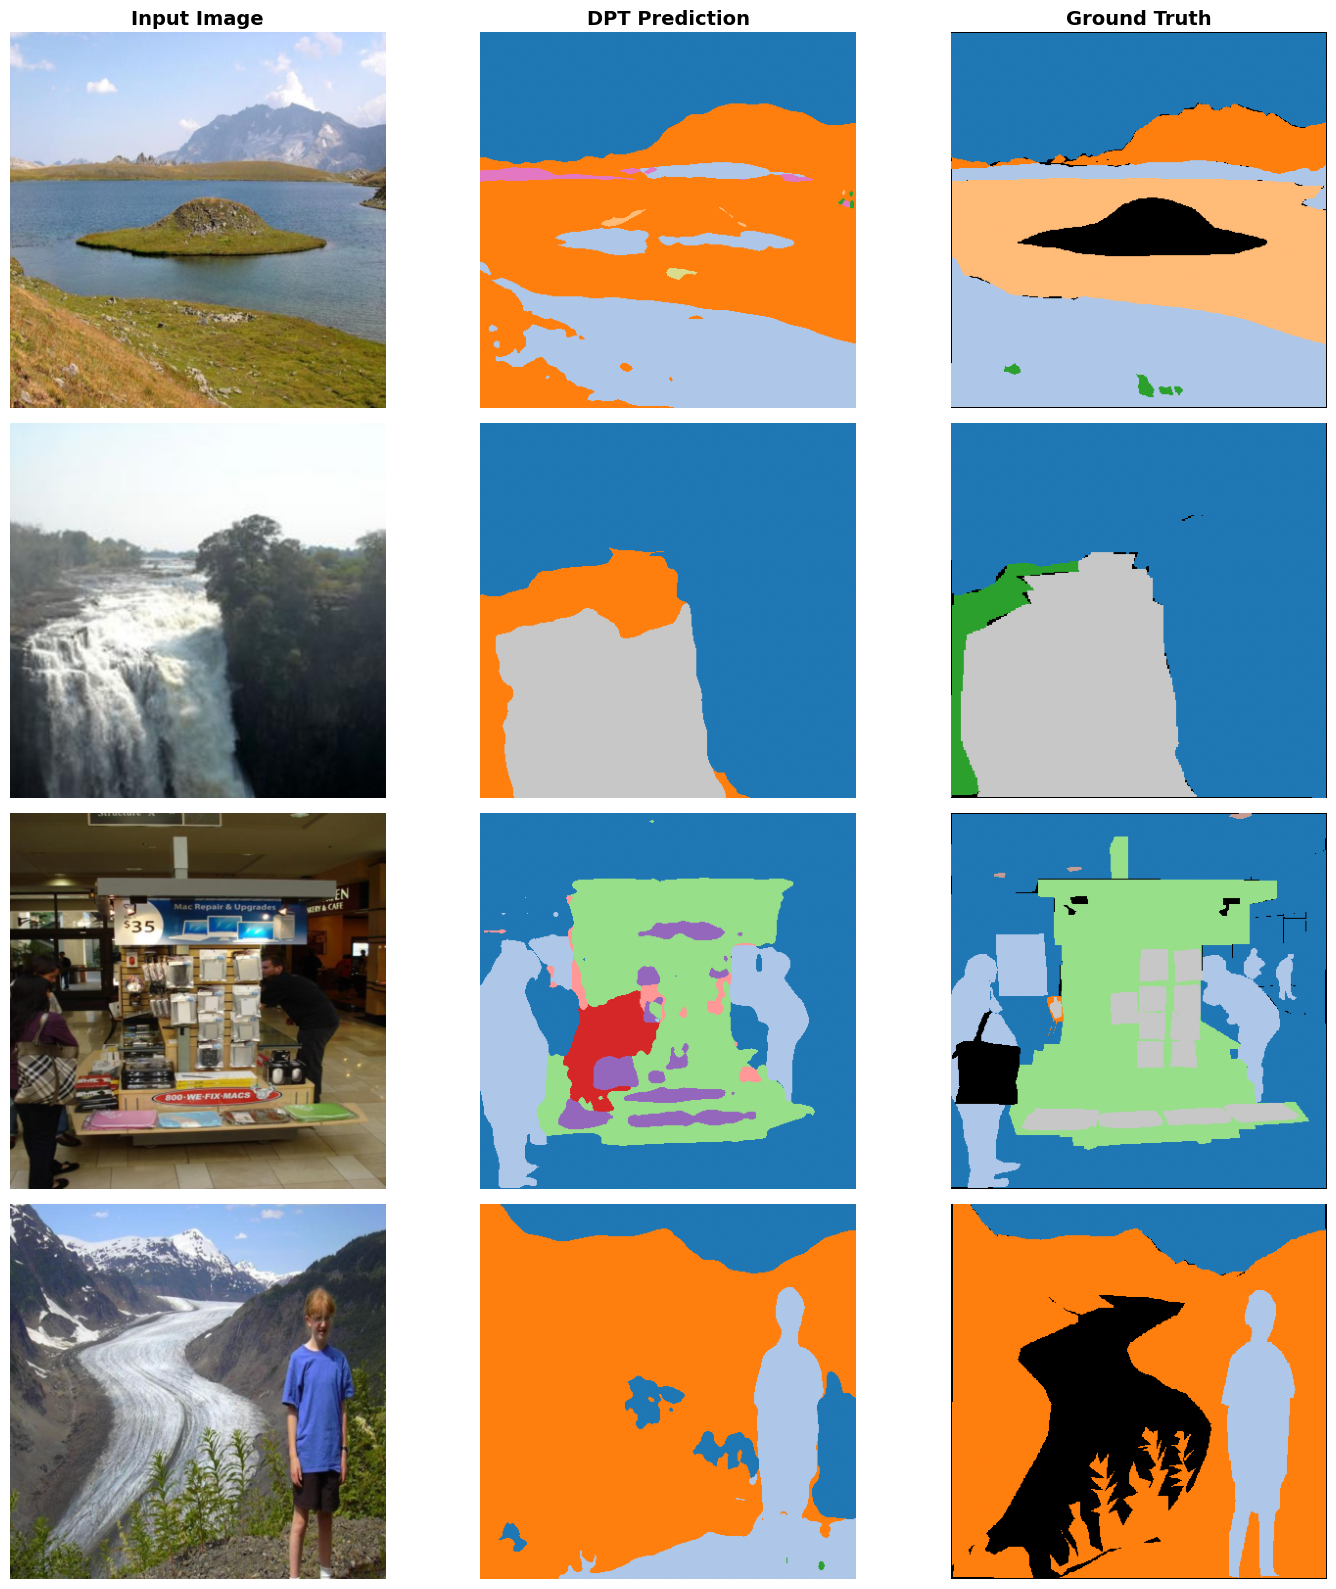

✅ Visualizations saved to: /kaggle/working/dpt_hybrid_ade20k_10pct_10ep_20260412_191626/dpt_visualizations.png


In [ ]:
# CELL 6 — Time-Efficient DPT Visualization
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

print("Generating quick sample predictions...")

# 1. Load the best saved checkpoint
best_model_path = f"{CONFIG['output_dir']}/dpt_best_model.pt"
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# 2. Select 4 random validation images
sample_idxs = np.random.choice(len(val_ds), min(4, len(val_ds)), replace=False)

# Use a consistent colormap for the 150 classes
cmap = plt.cm.get_cmap('tab20', CONFIG["num_classes"])
cmap.set_bad(color='black')

# 3. Create the plot layout
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes[0, 0].set_title("Input Image", fontweight='bold', fontsize=14)
axes[0, 1].set_title("DPT Prediction", fontweight='bold', fontsize=14)
axes[0, 2].set_title("Ground Truth", fontweight='bold', fontsize=14)

for i, idx in enumerate(sample_idxs):
    sample = val_ds[idx]
    
    # --- Fast Forward Pass ---
    with torch.no_grad():
        px = sample["pixel_values"].unsqueeze(0).to(device)
        with torch.cuda.amp.autocast(enabled=CONFIG["use_amp"]):
            logits = model(px)
        
        # Resize to match ground truth
        logits = F.interpolate(logits, size=sample["labels"].shape[-2:], mode='bilinear', align_corners=False)
        pred = logits.argmax(1).squeeze(0).cpu()

    
    img_np = sample["pixel_values"].cpu().permute(1, 2, 0).numpy()
    img_np = (img_np * 0.5) + 0.5  # Reverse normalization
    img_np = np.clip(img_np, 0, 1)
    
    # --- Process Masks ---
    pred_vis = pred.float().numpy()
    pred_vis[pred == -100] = np.nan
    
    true_vis = sample["labels"].float().numpy()
    true_vis[true_vis == -100] = np.nan

    # --- Plotting ---
    axes[i, 0].imshow(img_np)
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(pred_vis, cmap=cmap, vmin=0, vmax=CONFIG["num_classes"]-1)
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(true_vis, cmap=cmap, vmin=0, vmax=CONFIG["num_classes"]-1)
    axes[i, 2].axis("off")

plt.tight_layout()
viz_path = f"{CONFIG['output_dir']}/dpt_visualizations.png"
plt.savefig(viz_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Visualizations saved to: {viz_path}")